<a href="https://www.kaggle.com/code/lalit7881/smart-healthcare-and-lifestyle-prediction-eda?scriptVersionId=310946177" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/robiulhasanjisan/smart-healthcare-and-lifestyle-prediction-dataset/smart_healthcare_dataset.csv")

In [3]:
df.head()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
0,56,Male,22.6,2,1,1,169,225,74,0,1,0,0,0,0,100.0
1,69,Female,28.2,0,1,1,136,230,198,0,1,0,1,1,1,100.0
2,46,Female,25.1,1,0,1,142,221,89,0,1,1,0,0,0,100.0
3,32,Female,18.0,0,0,1,173,296,152,1,0,0,0,0,0,100.0
4,60,Female,20.1,2,1,0,130,292,133,1,1,1,0,1,0,100.0


In [4]:
df.tail()

,age,gender,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
4995,42,Female,15.3,2,1,1,92,292,121,0,1,1,0,0,0,100.0
4996,39,Female,24.2,0,1,1,140,156,83,0,0,0,0,0,0,100.0
4997,48,Female,19.2,2,0,0,135,247,89,1,1,1,0,0,0,100.0
4998,34,Male,24.0,0,1,1,144,254,187,1,1,1,0,0,0,100.0
4999,72,Female,29.9,1,0,1,115,179,121,1,0,0,1,1,1,100.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   age                5000 non-null   int64  
 1   gender             5000 non-null   object 
 2   bmi                5000 non-null   float64
 3   exercise_level     5000 non-null   int64  
 4   smoking            5000 non-null   int64  
 5   alcohol            5000 non-null   int64  
 6   blood_pressure     5000 non-null   int64  
 7   cholesterol        5000 non-null   int64  
 8   glucose            5000 non-null   int64  
 9   fatigue            5000 non-null   int64  
 10  chest_pain         5000 non-null   int64  
 11  dizziness          5000 non-null   int64  
 12  heart_disease      5000 non-null   int64  
 13  diabetes           5000 non-null   int64  
 14  stroke             5000 non-null   int64  
 15  health_risk_score  5000 non-null   float64
dtypes: float64(2), int64(13)

In [6]:
df.describe()

,age,bmi,exercise_level,smoking,alcohol,blood_pressure,cholesterol,glucose,fatigue,chest_pain,dizziness,heart_disease,diabetes,stroke,health_risk_score
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0
mean,48.805600,24.967800,1.005800,0.507600,0.501400,134.445400,224.616400,134.497400,0.515200,0.504000,0.497400,0.299800,0.349200,0.248600,100.0
std,17.906991,4.960379,0.815291,0.499992,0.500048,26.191438,43.129773,37.437028,0.499819,0.500034,0.500043,0.458216,0.476765,0.432245,0.0
min,18.000000,15.000000,0.000000,0.000000,0.000000,90.000000,150.000000,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
25%,34.000000,21.500000,0.000000,0.000000,0.000000,111.000000,187.000000,102.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.0
50%,49.000000,24.900000,1.000000,1.000000,1.000000,134.000000,226.000000,134.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,100.0
75%,64.000000,28.400000,2.000000,1.000000,1.000000,157.000000,262.000000,167.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,100.0
max,79.000000,42.600000,2.000000,1.000000,1.000000,179.000000,299.000000,199.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,100.0


In [7]:
df.isnull().sum()

age                  0
gender               0
bmi                  0
exercise_level       0
smoking              0
alcohol              0
blood_pressure       0
cholesterol          0
glucose              0
fatigue              0
chest_pain           0
dizziness            0
heart_disease        0
diabetes             0
stroke               0
health_risk_score    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

age                    int64
gender                object
bmi                  float64
exercise_level         int64
smoking                int64
alcohol                int64
blood_pressure         int64
cholesterol            int64
glucose                int64
fatigue                int64
chest_pain             int64
dizziness              int64
heart_disease          int64
diabetes               int64
stroke                 int64
health_risk_score    float64
dtype: object

In [10]:
df.shape

(5000, 16)

In [11]:
df.columns

Index(['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol',
       'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain',
       'dizziness', 'heart_disease', 'diabetes', 'stroke',
       'health_risk_score'],
      dtype='object')

In [12]:
df.nunique()

age                   62
gender                 2
bmi                  248
exercise_level         3
smoking                2
alcohol                2
blood_pressure        90
cholesterol          150
glucose              130
fatigue                2
chest_pain             2
dizziness              2
heart_disease          2
diabetes               2
stroke                 2
health_risk_score      1
dtype: int64

## EDA

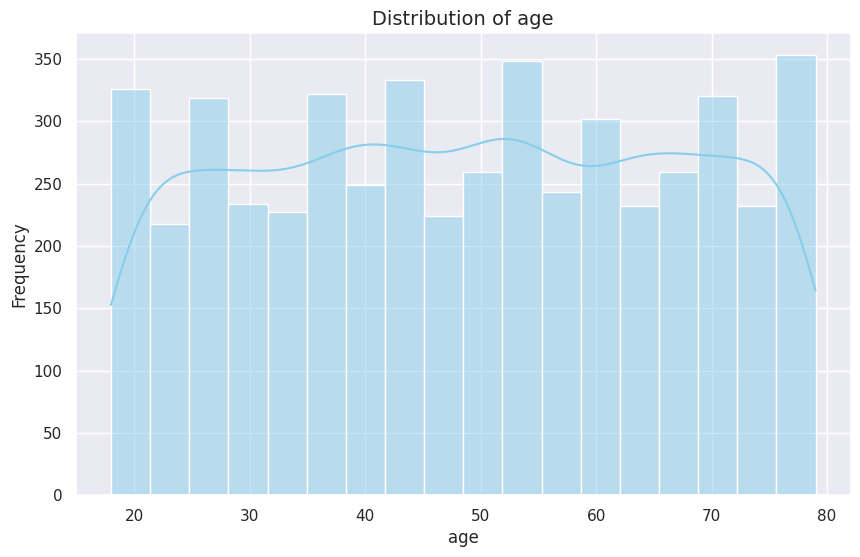

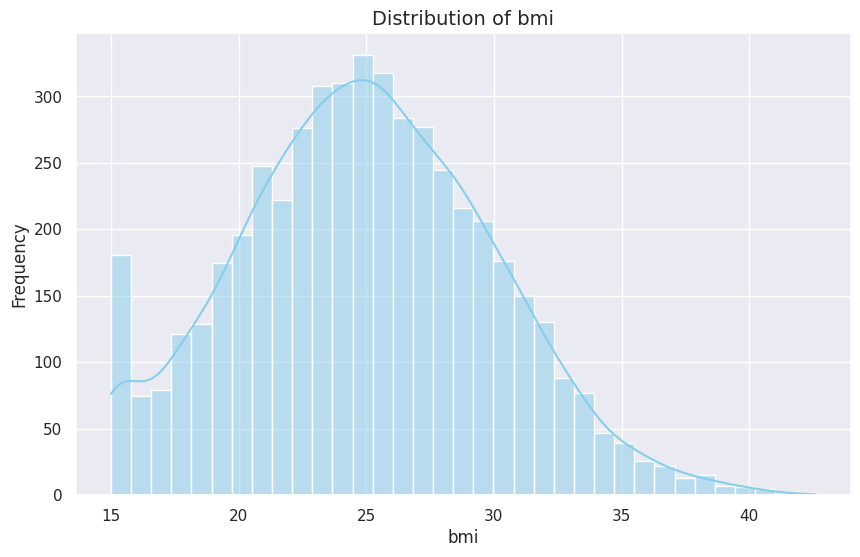

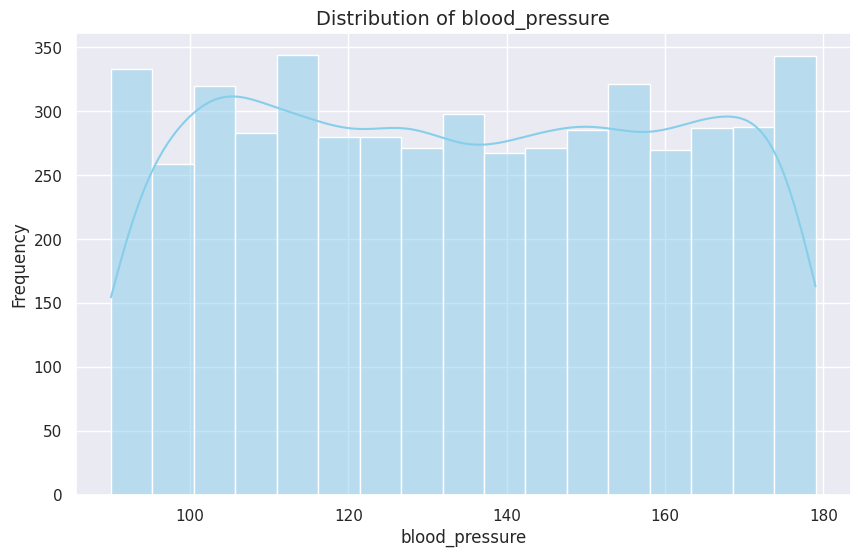

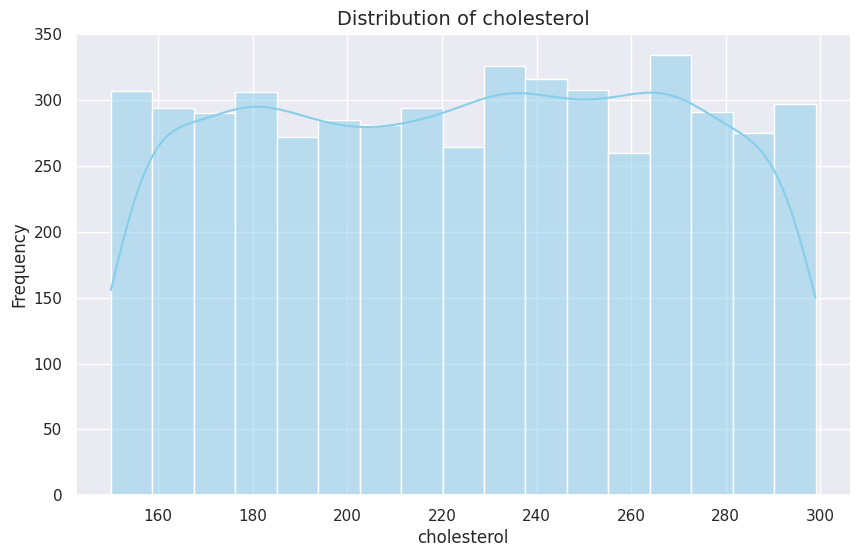

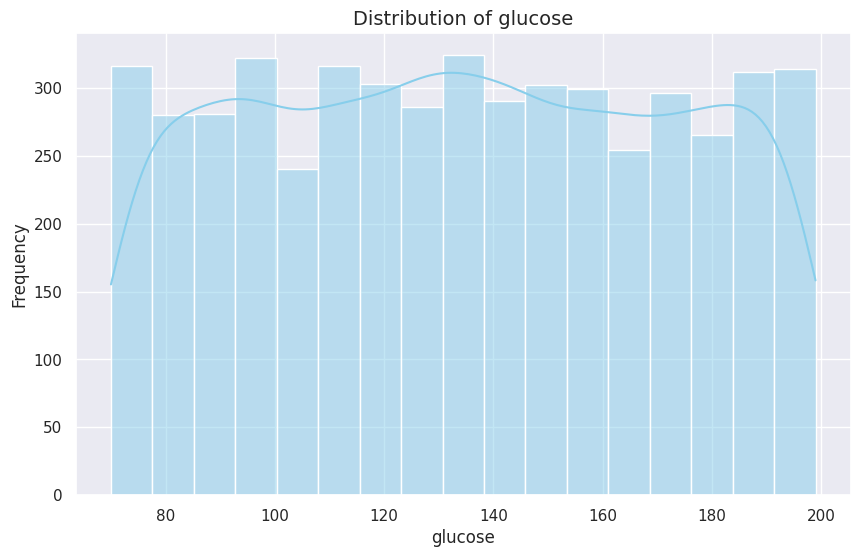

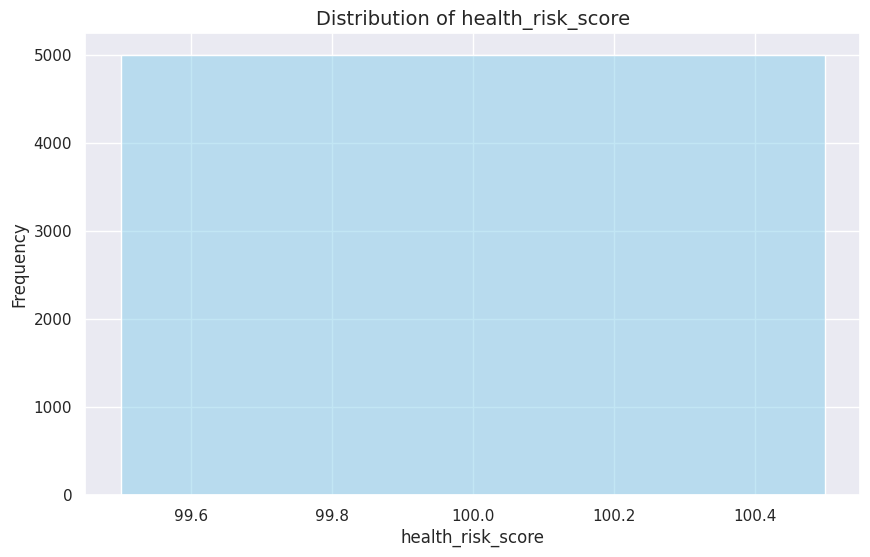

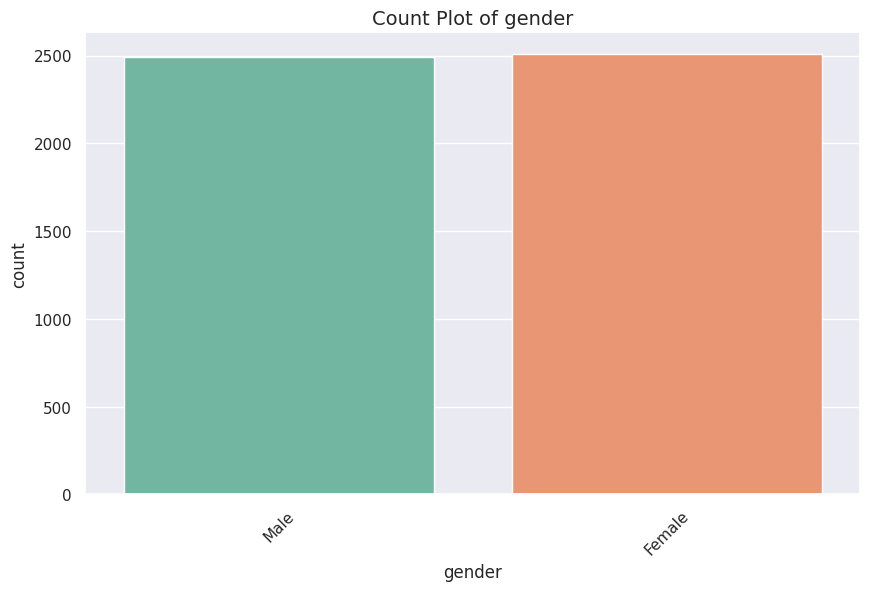

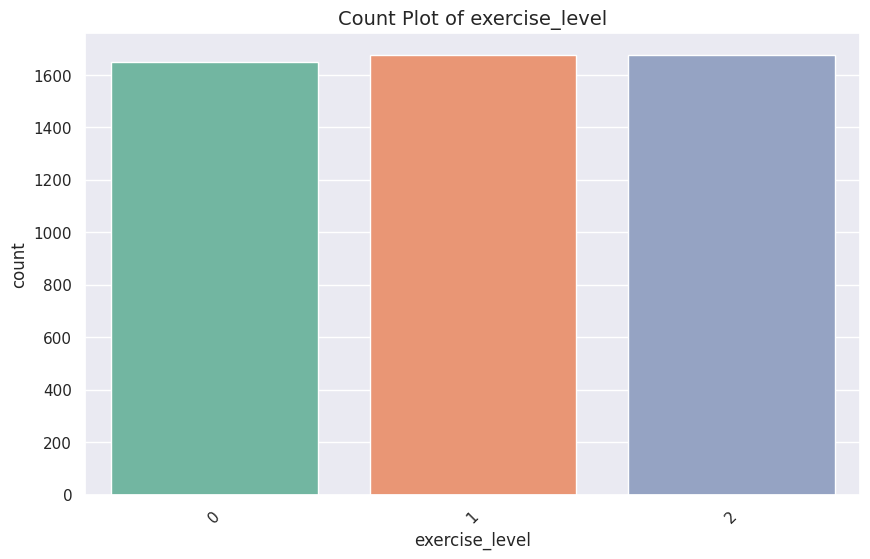

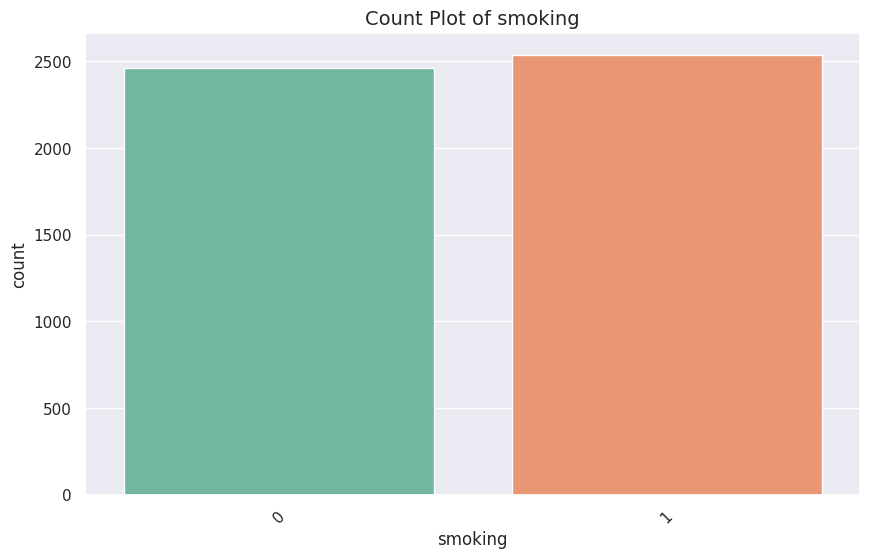

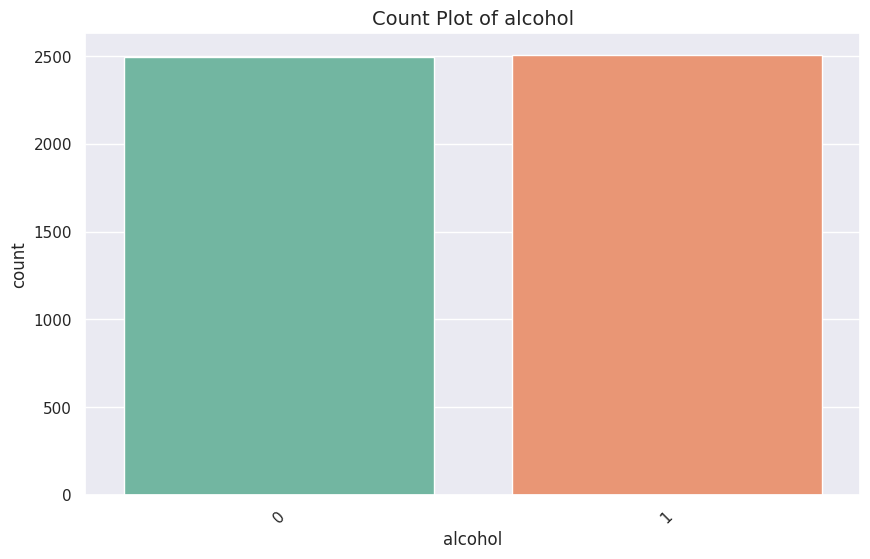

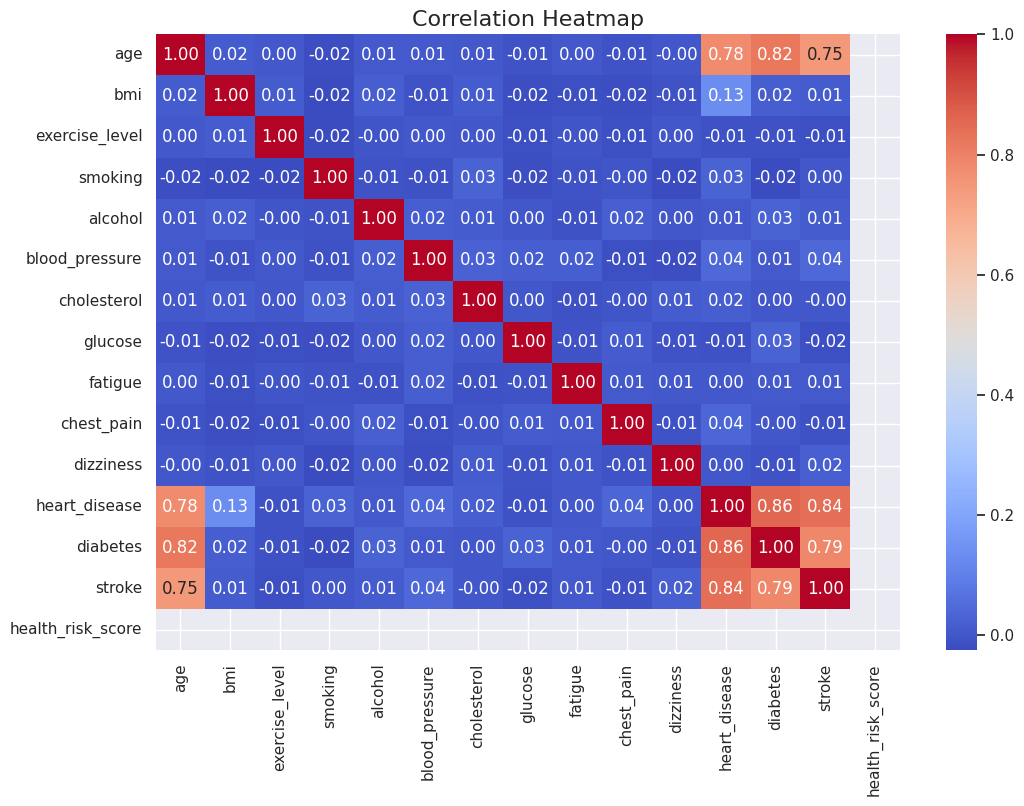

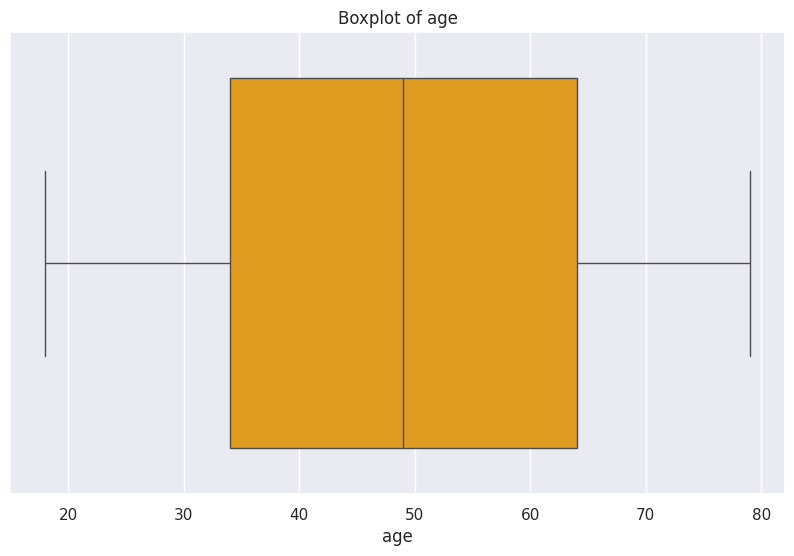

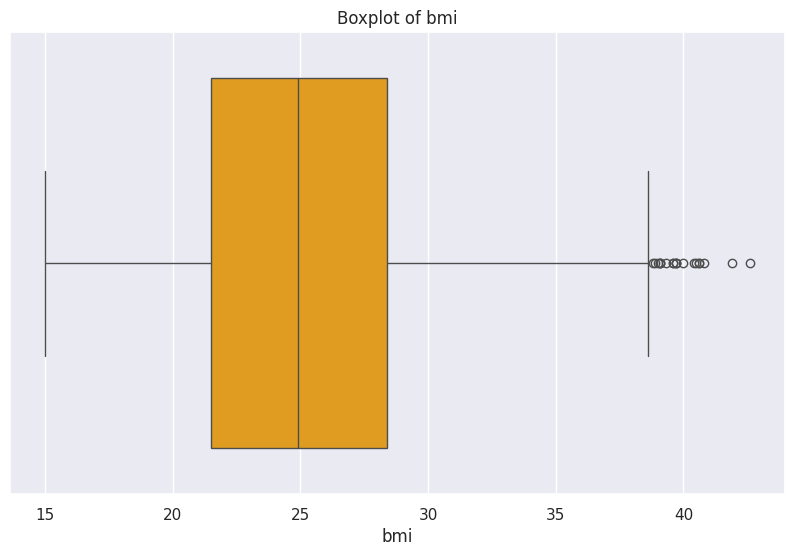

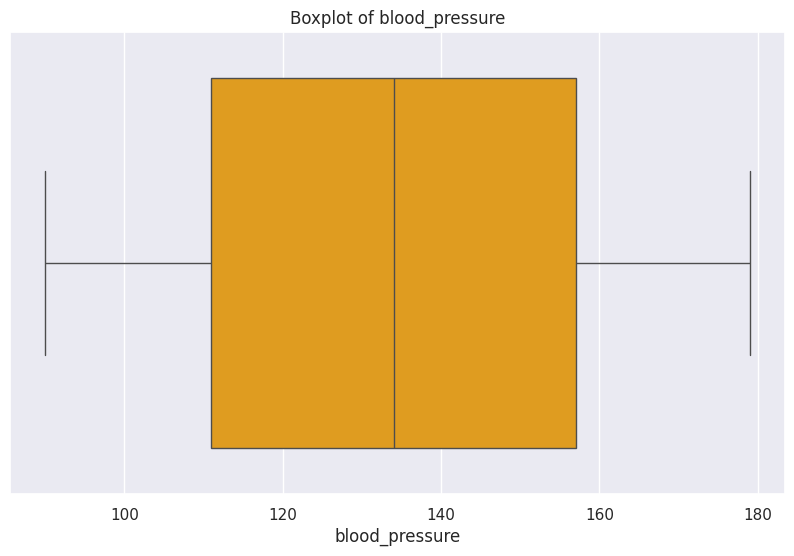

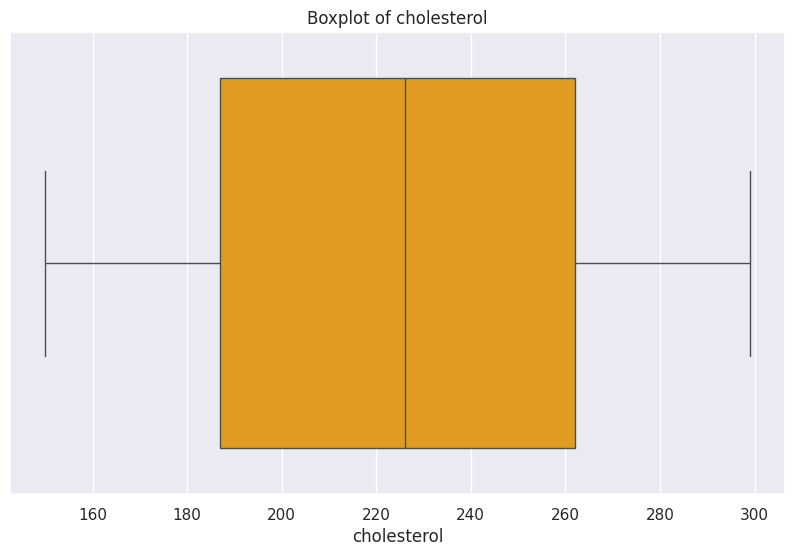

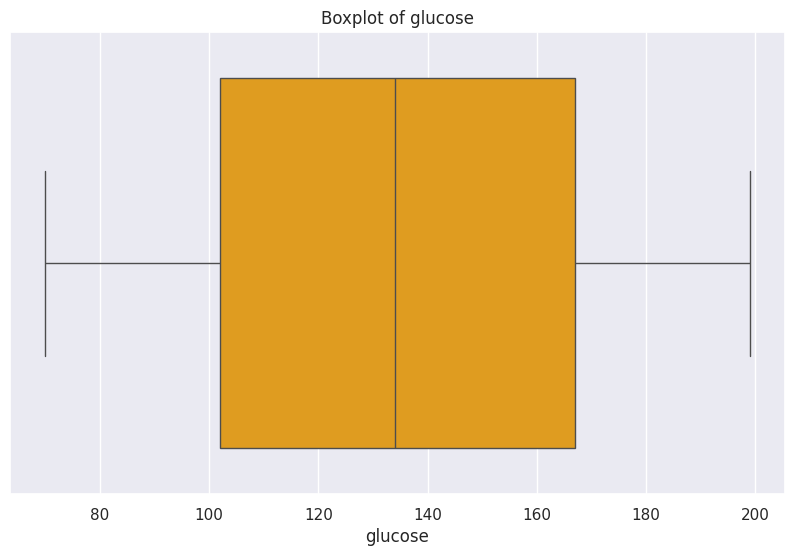

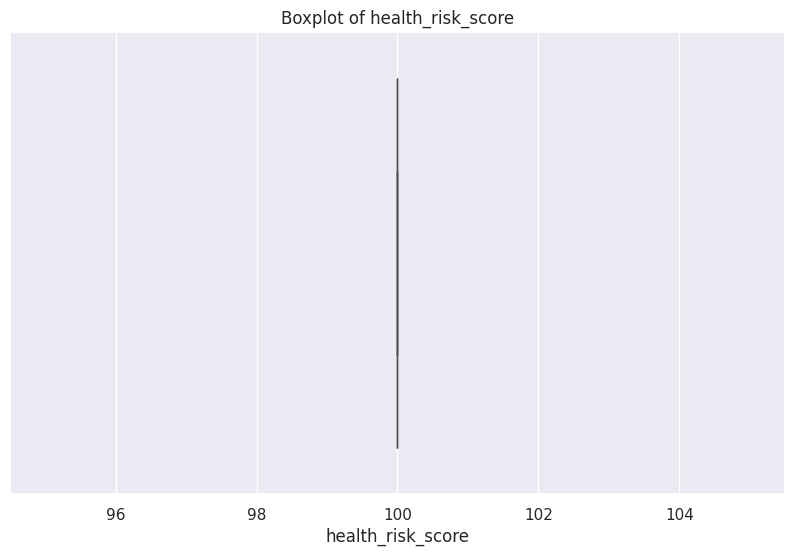

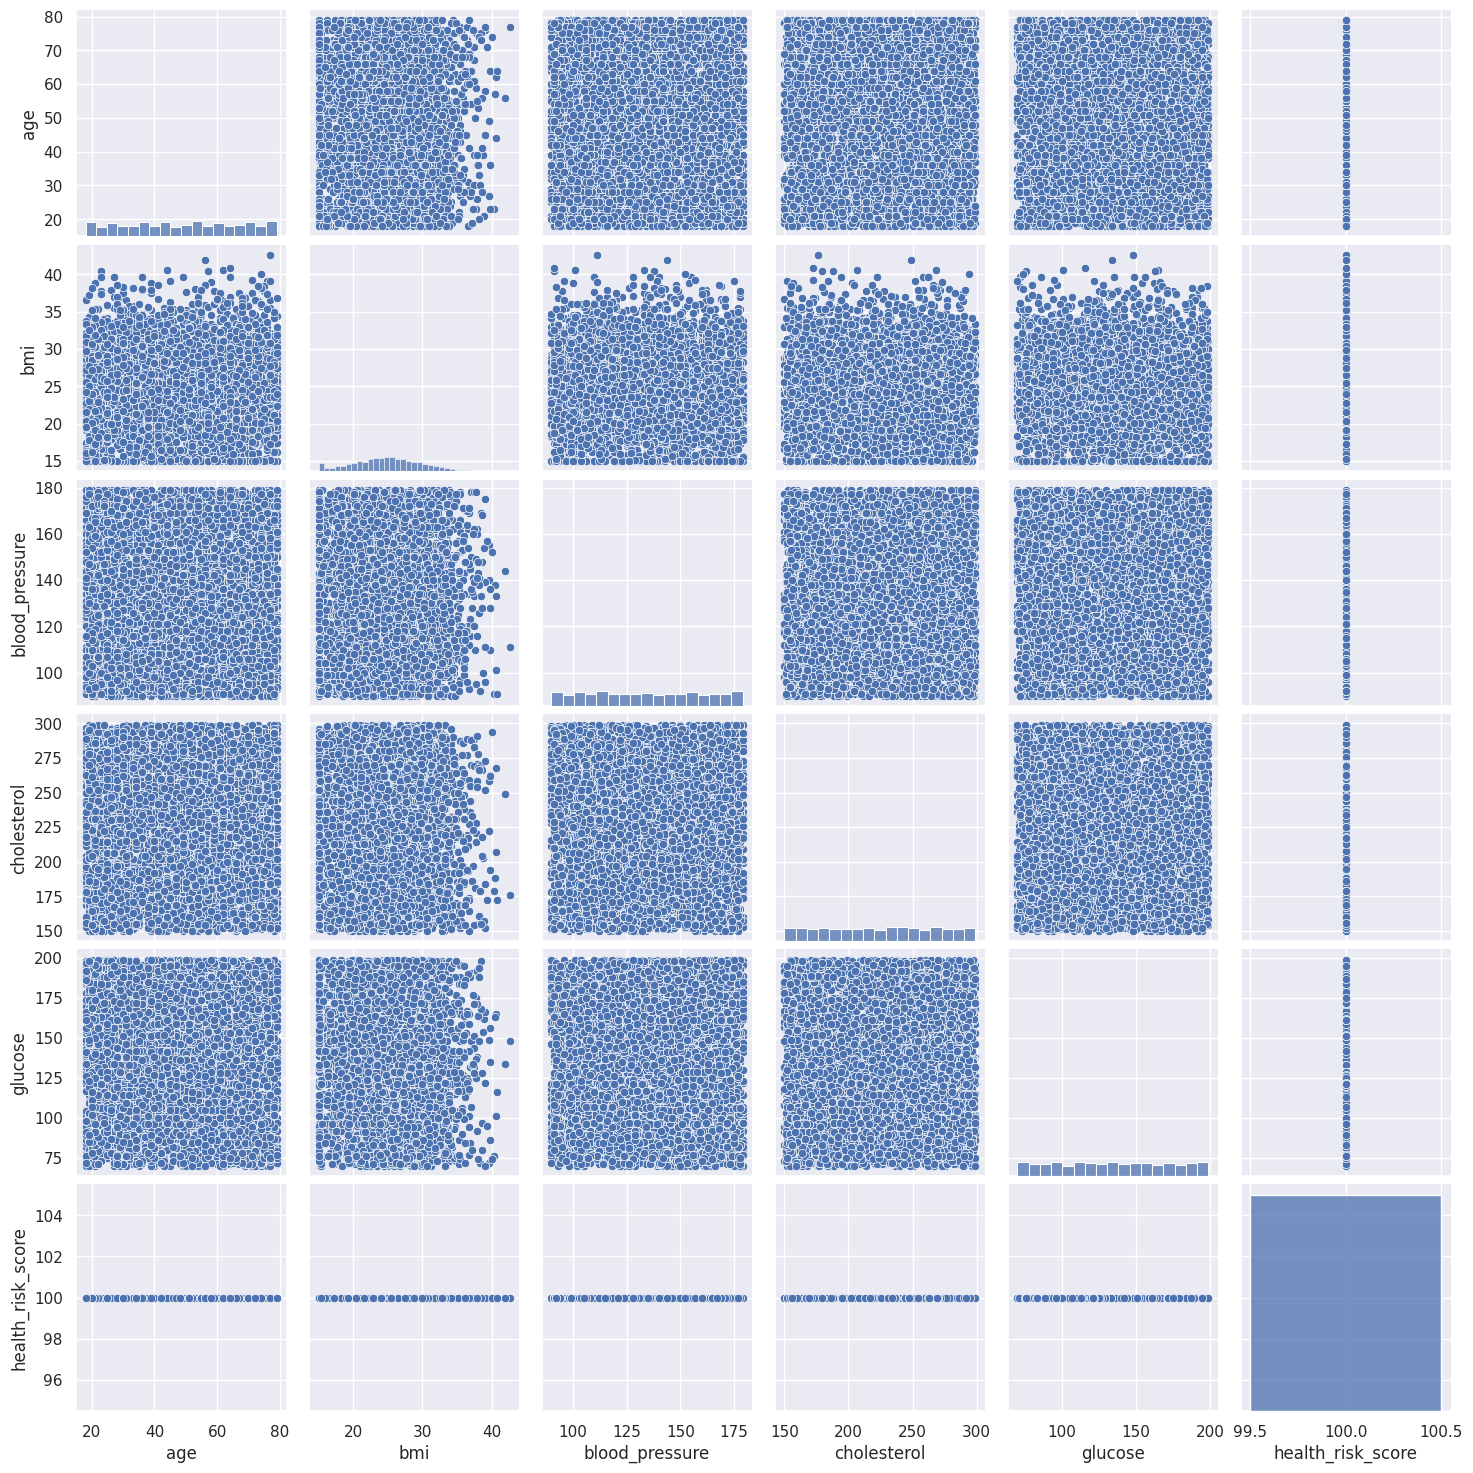

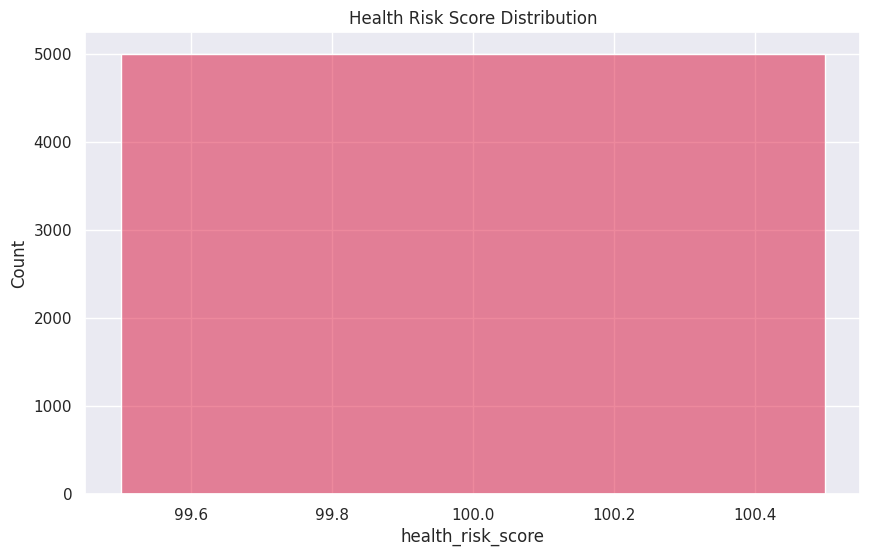

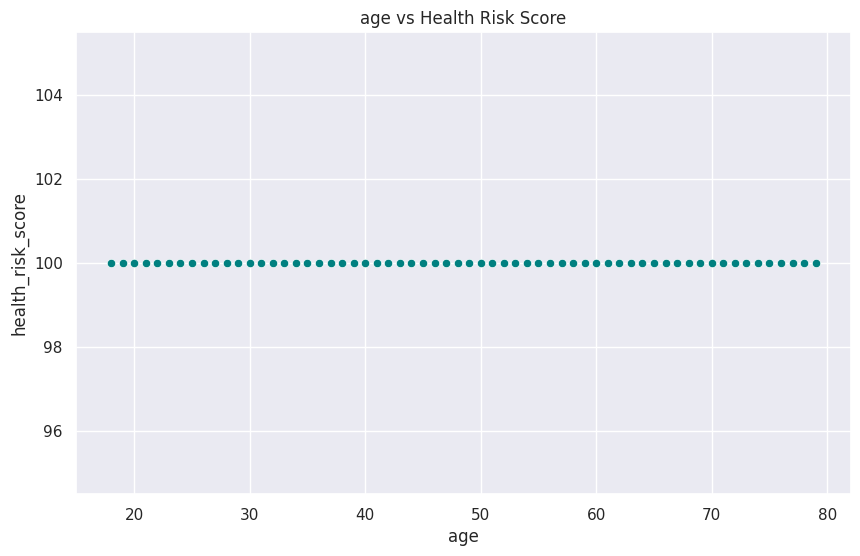

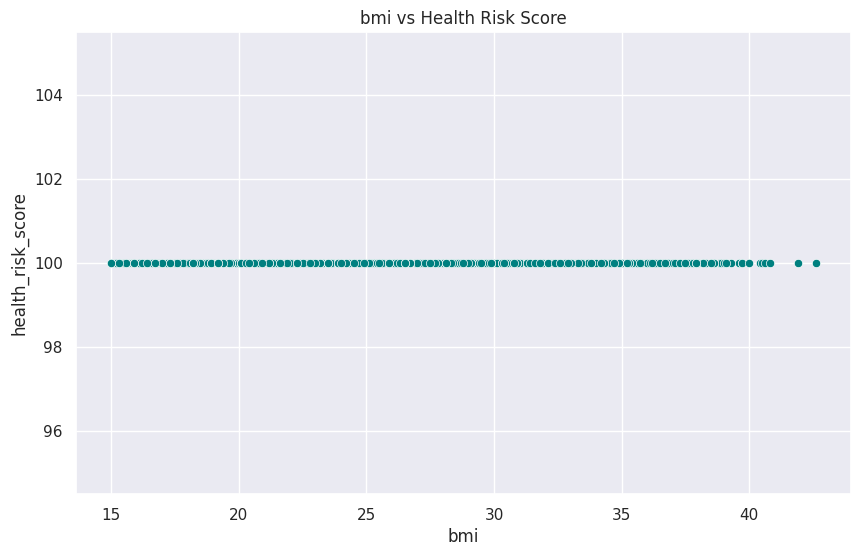

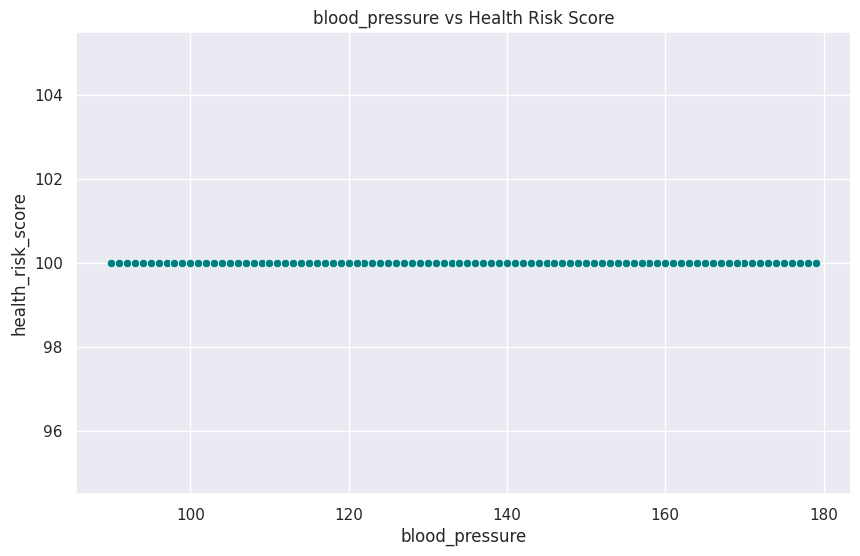

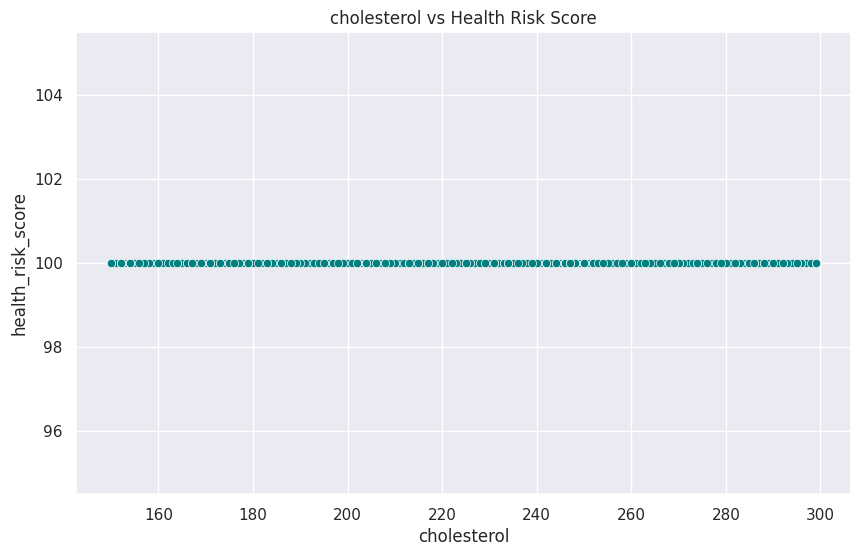

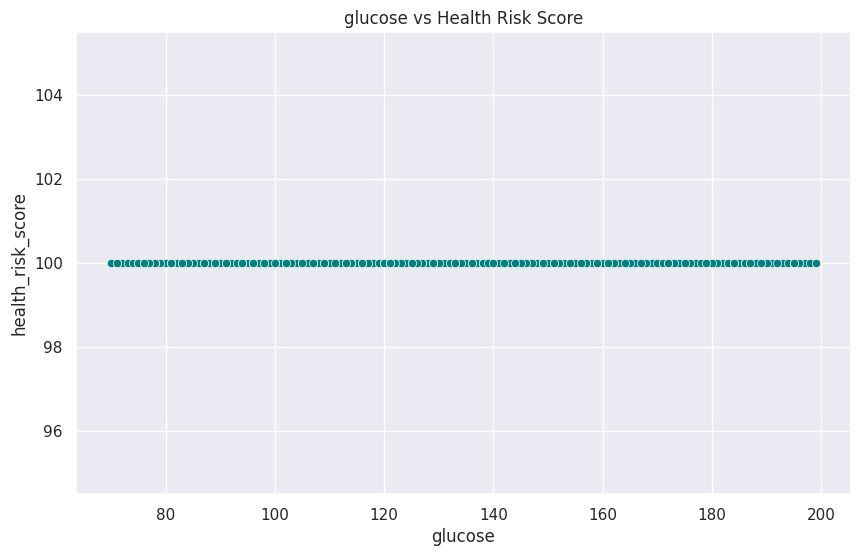

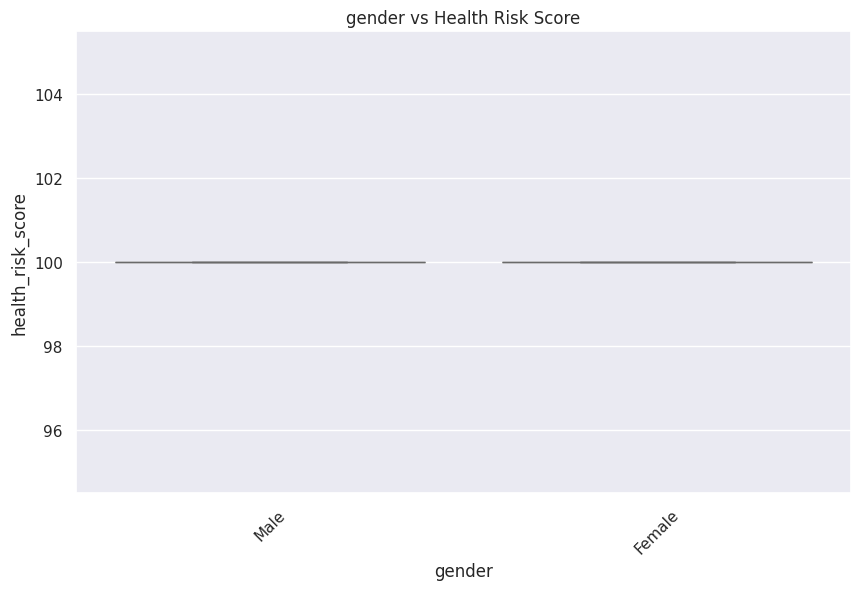

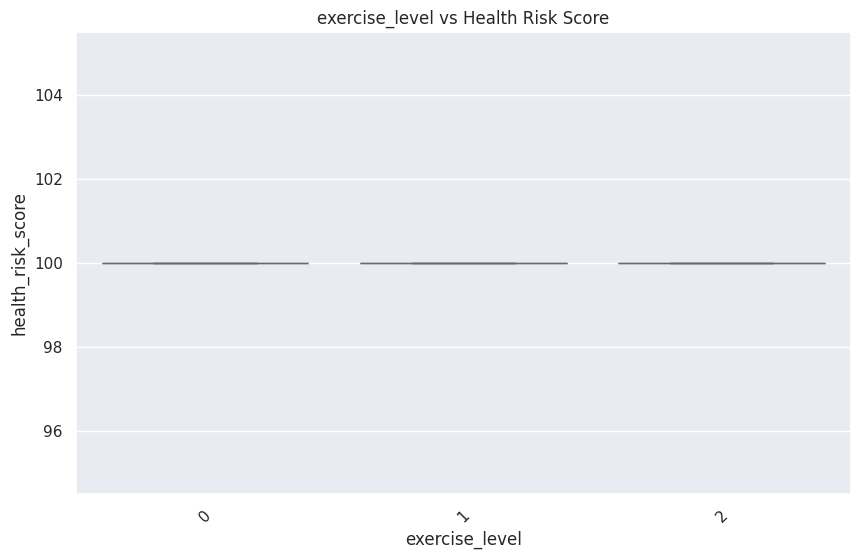

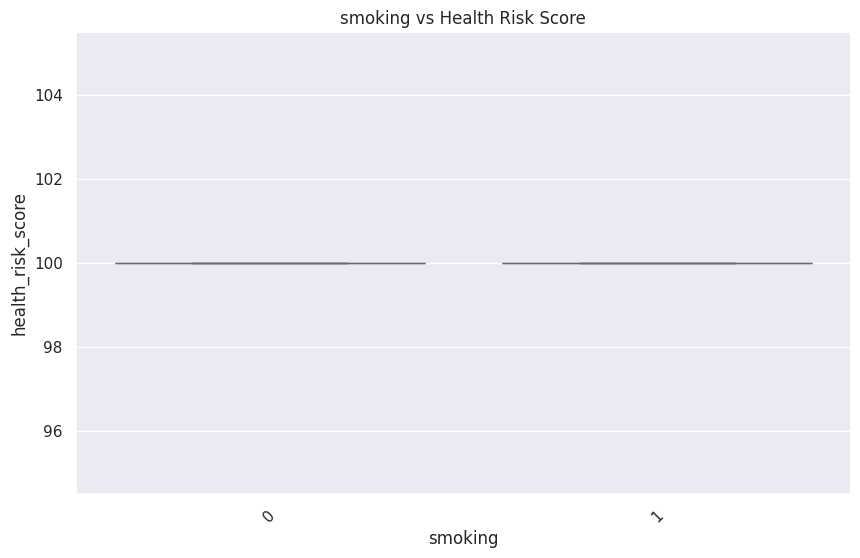

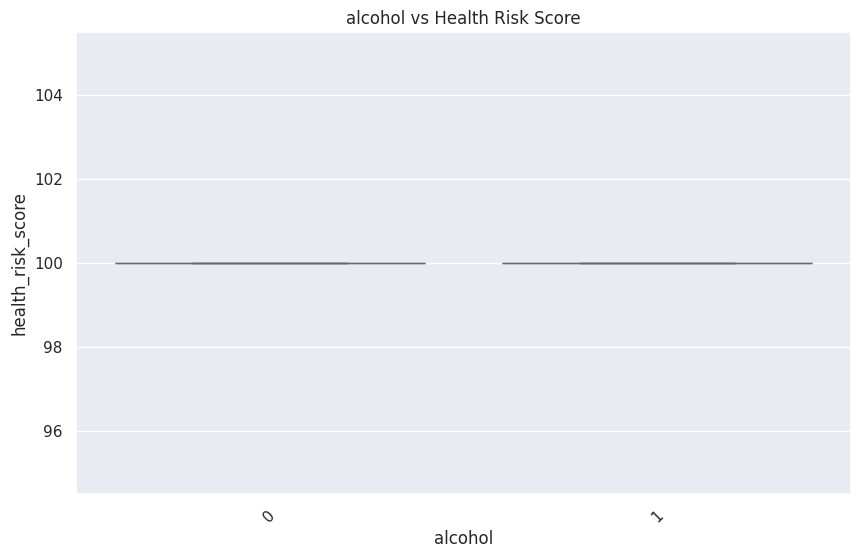

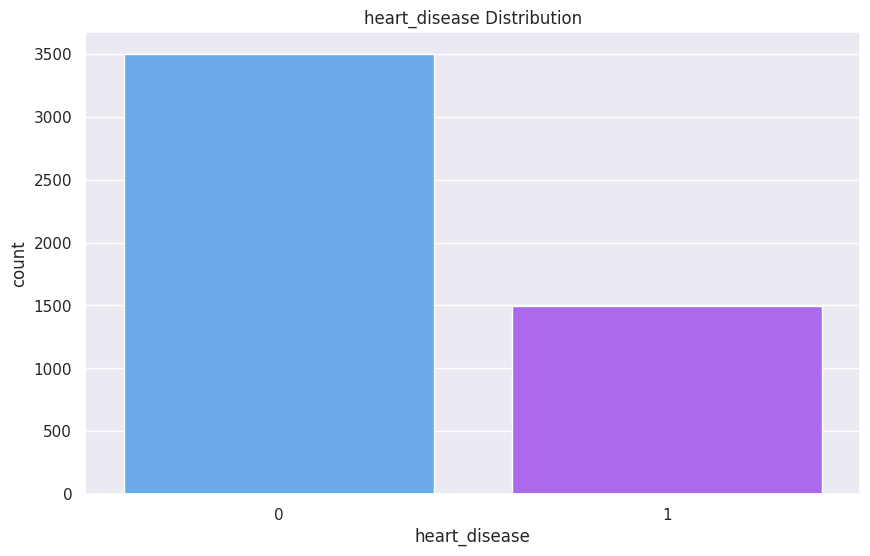

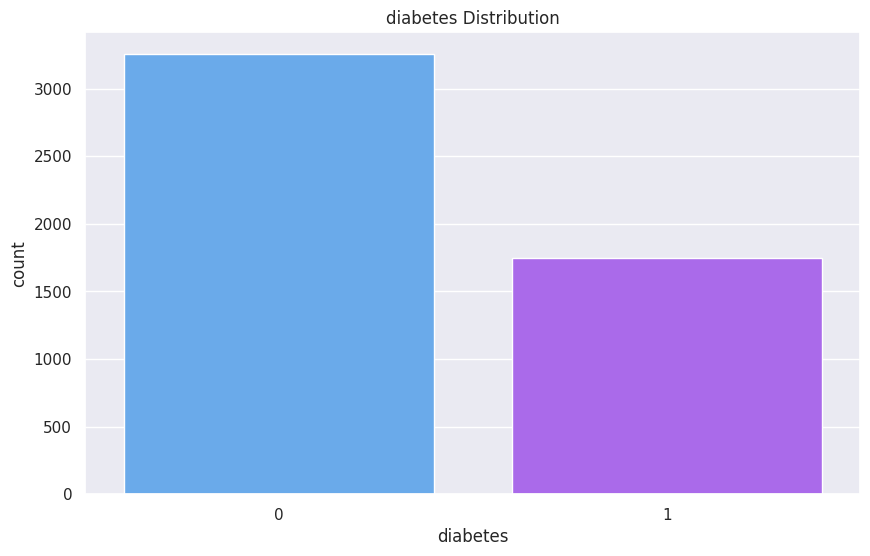

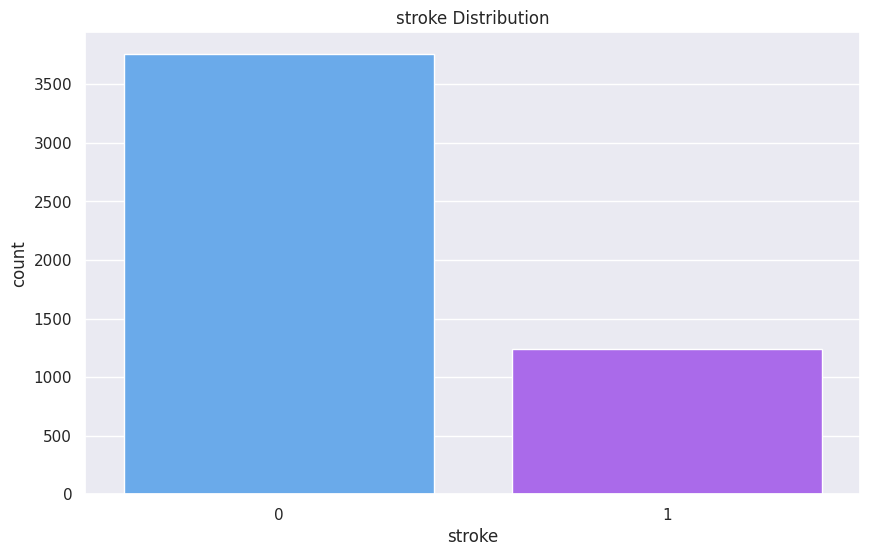

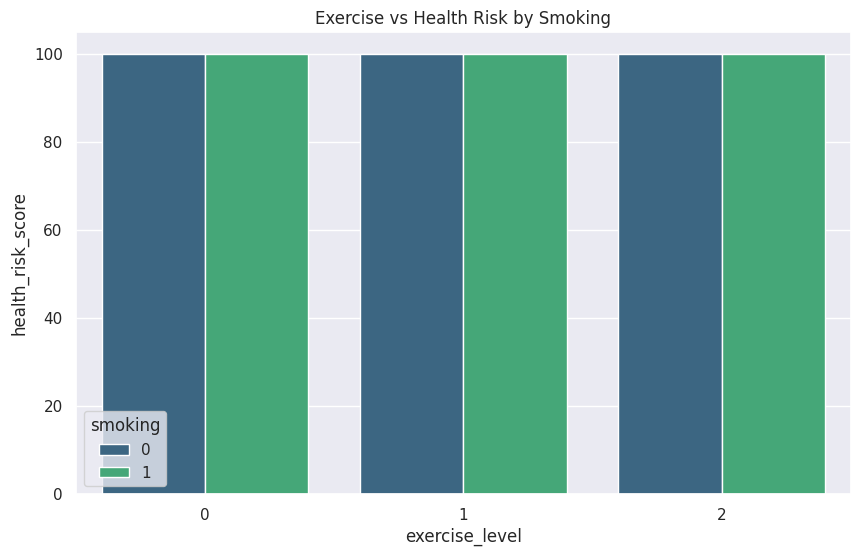

In [13]:
# ================================
# Style Settings
# ================================
sns.set(style="darkgrid")
plt.rcParams['figure.figsize'] = (10, 6)

# ================================
# 1. Distribution Plots (Numerical)
# ================================
num_cols = ['age', 'bmi', 'blood_pressure', 'cholesterol', 'glucose', 'health_risk_score']

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f'Distribution of {col}', fontsize=14)
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# ================================
# 2. Count Plots (Categorical)
# ================================
cat_cols = ['gender', 'exercise_level', 'smoking', 'alcohol']

colors = ['red', 'green', 'blue', 'purple']

for col, color in zip(cat_cols, colors):
    plt.figure()
    sns.countplot(x=df[col], palette='Set2')
    plt.title(f'Count Plot of {col}', fontsize=14)
    plt.xticks(rotation=45)
    plt.show()

# ================================
# 3. Correlation Heatmap
# ================================
plt.figure(figsize=(12, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap', fontsize=16)
plt.show()

# ================================
# 4. Boxplots (Outlier Detection)
# ================================
for col in num_cols:
    plt.figure()
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Boxplot of {col}')
    plt.show()

# ================================
# 5. Pairplot (Multivariate Analysis)
# ================================
sns.pairplot(df[num_cols], palette='husl')
plt.show()

# ================================
# 6. Target Analysis (Health Risk)
# ================================
plt.figure()
sns.histplot(df['health_risk_score'], kde=True, color='crimson')
plt.title('Health Risk Score Distribution')
plt.show()

# ================================
# 7. Feature vs Target Relationships
# ================================
for col in num_cols:
    if col != 'health_risk_score':
        plt.figure()
        sns.scatterplot(x=df[col], y=df['health_risk_score'], color='teal')
        plt.title(f'{col} vs Health Risk Score')
        plt.show()

# ================================
# 8. Categorical vs Target
# ================================
for col in cat_cols:
    plt.figure()
    sns.boxplot(x=df[col], y=df['health_risk_score'], palette='Set3')
    plt.title(f'{col} vs Health Risk Score')
    plt.xticks(rotation=45)
    plt.show()

# ================================
# 9. Disease Count Visualization
# ================================
disease_cols = ['heart_disease', 'diabetes', 'stroke']

for col in disease_cols:
    plt.figure()
    sns.countplot(x=df[col], palette='cool')
    plt.title(f'{col} Distribution')
    plt.show()

# ================================
# 10. Multi-feature Comparison
# ================================
plt.figure(figsize=(10,6))
sns.barplot(x='exercise_level', y='health_risk_score', hue='smoking', data=df, palette='viridis')
plt.title('Exercise vs Health Risk by Smoking')
plt.show()

## Feature engineering

In [14]:
print(df.columns)

Index(['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol',
       'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain',
       'dizziness', 'heart_disease', 'diabetes', 'stroke',
       'health_risk_score'],
      dtype='object')


Dataset Shape: (5000, 16)

Columns:
 Index(['age', 'gender', 'bmi', 'exercise_level', 'smoking', 'alcohol',
       'blood_pressure', 'cholesterol', 'glucose', 'fatigue', 'chest_pain',
       'dizziness', 'heart_disease', 'diabetes', 'stroke',
       'health_risk_score'],
      dtype='object')

Target Distribution:
 target
0    3757
1    1243
Name: count, dtype: int64

Train Target Distribution:
 target
0    3006
1     994
Name: count, dtype: int64

Logistic Regression
Accuracy: 0.9790

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.97      0.99       751
           1       0.93      1.00      0.96       249

    accuracy                           0.98      1000
   macro avg       0.96      0.98      0.97      1000
weighted avg       0.98      0.98      0.98      1000



<Figure size 1000x700 with 0 Axes>

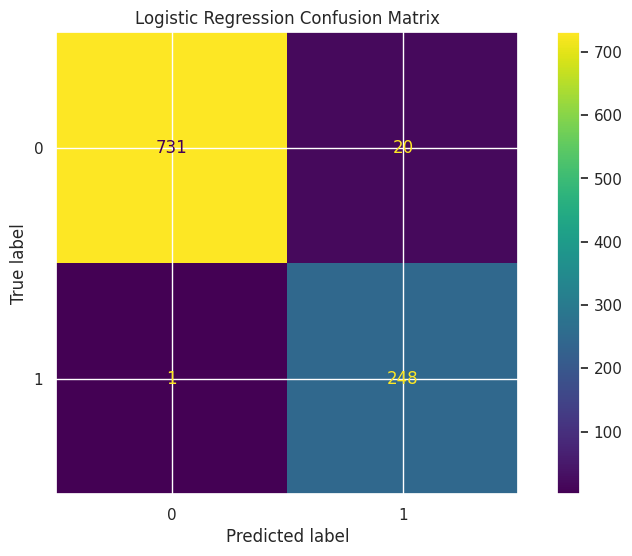


Random Forest
Accuracy: 0.9910

Classification Report:
               precision    recall  f1-score   support

           0       0.99      1.00      0.99       751
           1       0.99      0.98      0.98       249

    accuracy                           0.99      1000
   macro avg       0.99      0.99      0.99      1000
weighted avg       0.99      0.99      0.99      1000



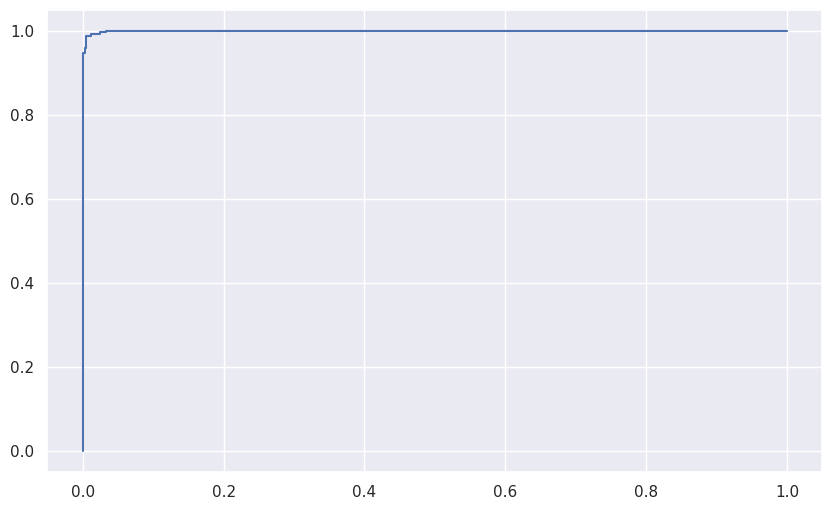

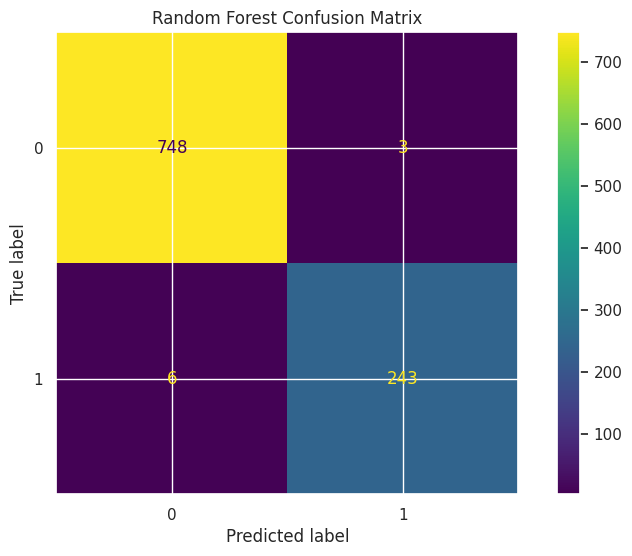


Gradient Boosting
Accuracy: 1.0000

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       751
           1       1.00      1.00      1.00       249

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



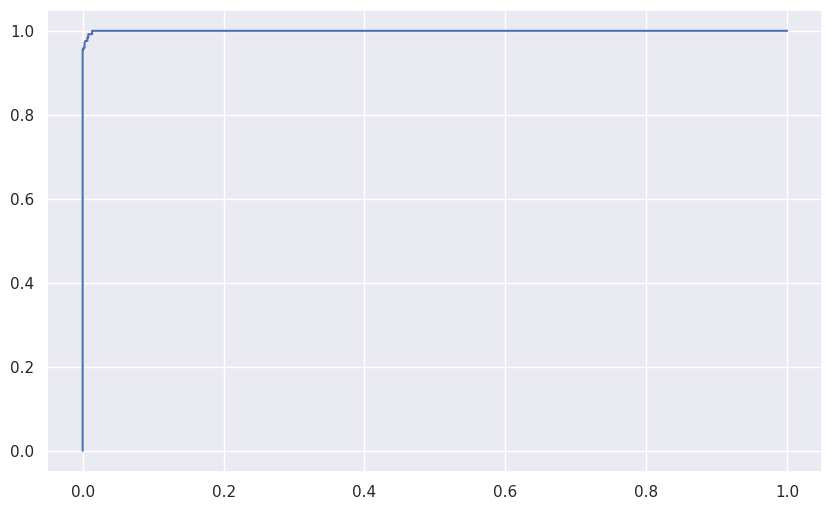

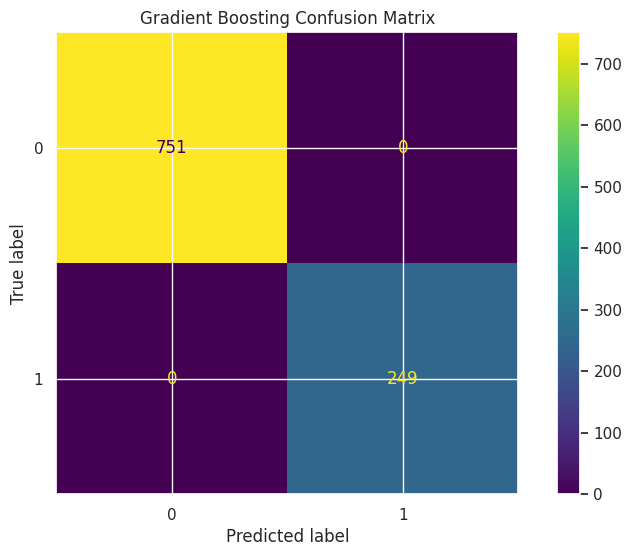


SVM
Accuracy: 0.9720

Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.97      0.98       751
           1       0.92      0.98      0.95       249

    accuracy                           0.97      1000
   macro avg       0.95      0.97      0.96      1000
weighted avg       0.97      0.97      0.97      1000



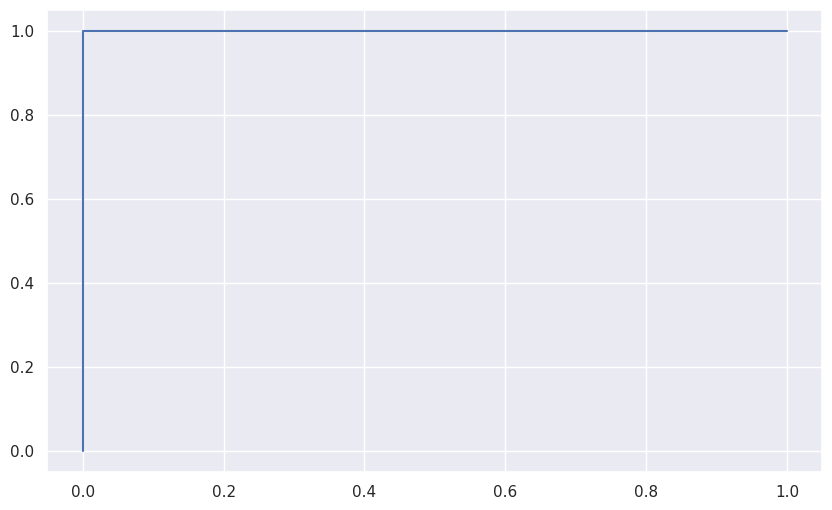

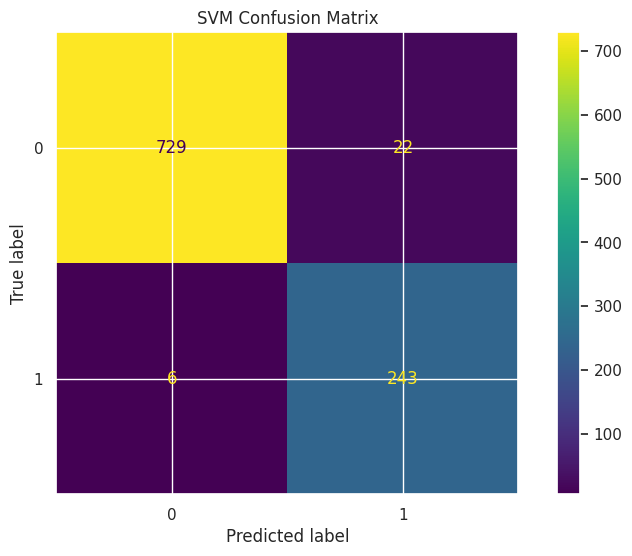

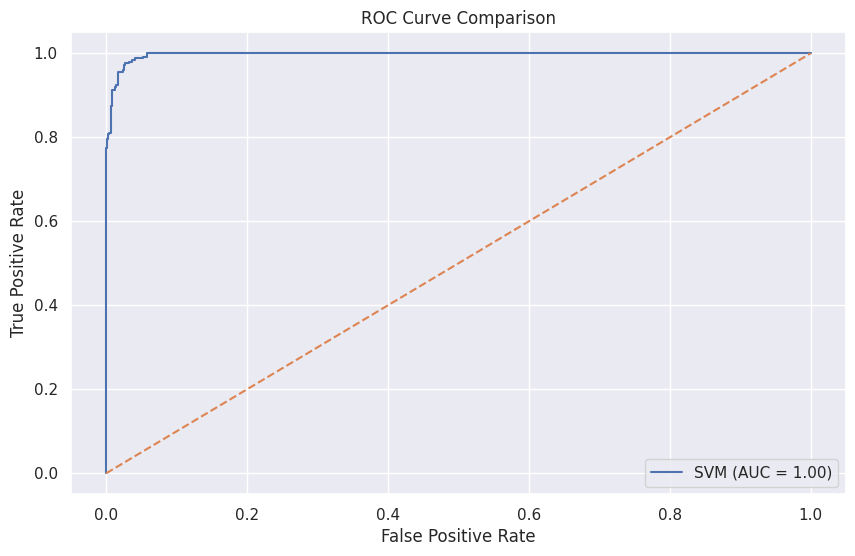


Final Model Accuracy:
Logistic Regression: 0.9790
Random Forest: 0.9910
Gradient Boosting: 1.0000
SVM: 0.9720


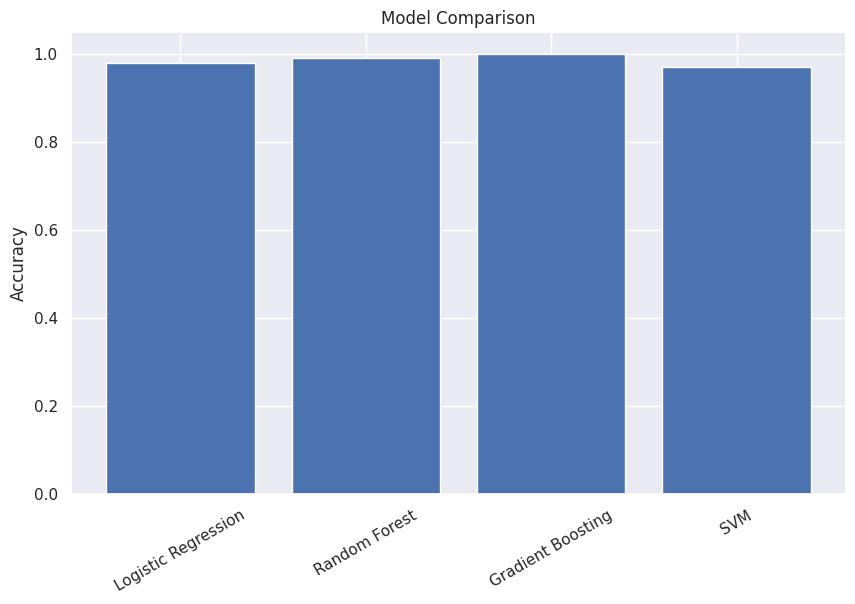

In [15]:
# ==========================================
# 1. Import Libraries
# ==========================================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import roc_curve, auc, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

# ==========================================
# 3. TARGET SELECTION (SAFE & BEST)
# ==========================================
# Using stroke as target (binary, reliable)
df['target'] = df['stroke']

# Drop columns NOT needed
df = df.drop(columns=['stroke', 'health_risk_score'], errors='ignore')

# Check target distribution
print("\nTarget Distribution:\n", df['target'].value_counts())

# ==========================================
# 4. Feature & Target Split
# ==========================================
X = df.drop(columns=['target'])
y = df['target']

# ==========================================
# 5. Column Types
# ==========================================
cat_cols = ['gender', 'exercise_level', 'smoking', 'alcohol']
num_cols = [col for col in X.columns if col not in cat_cols]

# ==========================================
# 6. Preprocessing (NO DATA LEAKAGE)
# ==========================================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# ==========================================
# 7. Train-Test Split (STRATIFIED)
# ==========================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nTrain Target Distribution:\n", y_train.value_counts())

# ==========================================
# 8. Models
# ==========================================
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=100, class_weight='balanced'),
    "Gradient Boosting": GradientBoostingClassifier(),
    "SVM": SVC(probability=True)
}

# ==========================================
# 9. Training + Evaluation
# ==========================================
results = {}

plt.figure(figsize=(10, 7))

for name, model in models.items():
    
    # Pipeline (Preprocessing + Model)
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])
    
    # Train
    pipe.fit(X_train, y_train)
    
    # Predict
    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("\n" + "="*50)
    print(name)
    print("="*50)
    print(f"Accuracy: {acc:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
    plt.title(f"{name} Confusion Matrix")
    plt.show()
    
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

# ==========================================
# 10. ROC Curve Comparison
# ==========================================
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

# ==========================================
# 11. Accuracy Comparison
# ==========================================
print("\nFinal Model Accuracy:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

plt.figure()
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.ylabel("Accuracy")
plt.title("Model Comparison")
plt.show()

## Thank you..pls upvote!!!!!!!!!
